Imported CSV file of Telco Customer Churn Analysis, where, we have done certain analytics on MySQL Workbench 8.0. Like, Overall Churn Rate, Segmentation Analysis (Grouping based on shared characteristics). We are going to analyze this grouped dataset from mysql workbench 8.0 based on tenure_group.

Here, tenure_group is low (if tenure <=6), mid (if tenure <= 12), else loyal.


In [83]:
import pandas as pd
df = pd.read_csv('/content/Customer_Churn_Analysis.csv')
print(df)

      customerID  gender  tenure  MonthlyCharges  TotalCharges  \
0     7590-VHVEG  Female       1           29.85         29.85   
1     5575-GNVDE    Male      34           56.95       1889.50   
2     3668-QPYBK    Male       2           53.85        108.15   
3     7795-CFOCW    Male      45           42.30       1840.75   
4     9237-HQITU  Female       2           70.70        151.65   
...          ...     ...     ...             ...           ...   
5507  6840-RESVB    Male      24           84.80       1990.50   
5508  2234-XADUH  Female      72          103.20       7362.90   
5509  4801-JZAZL  Female      11           29.60        346.45   
5510  8361-LTMKD    Male       4           74.40        306.60   
5511  3186-AJIEK    Male      66          105.65       6844.50   

            Contract InternetService              PaymentMethod tenure_group  \
0     Month-to-month             DSL           Electronic check          New   
1           One year             DSL           

In [84]:
details = df.describe()
print(details)

            tenure  MonthlyCharges  TotalCharges
count  5512.000000     5512.000000   5512.000000
mean     32.905479       76.855053   2729.505406
std      24.584848       21.929331   2355.681063
min       1.000000       23.450000     23.450000
25%       9.000000       59.950000    586.837500
50%      30.000000       79.500000   2139.150000
75%      56.000000       94.450000   4528.000000
max      72.000000      118.750000   8684.800000


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5512 entries, 0 to 5511
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       5512 non-null   object 
 1   gender           5512 non-null   object 
 2   tenure           5512 non-null   int64  
 3   MonthlyCharges   5512 non-null   float64
 4   TotalCharges     5512 non-null   float64
 5   Contract         5512 non-null   object 
 6   InternetService  5512 non-null   object 
 7   PaymentMethod    5512 non-null   object 
 8   tenure_group     5512 non-null   object 
 9   Churn            5512 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 430.8+ KB


In [86]:
df.isna().sum()

,0
customerID,0
gender,0
tenure,0
MonthlyCharges,0
TotalCharges,0
Contract,0
InternetService,0
PaymentMethod,0
tenure_group,0
Churn,0


In [87]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

In [88]:
print(df['TotalCharges'].astype(str).str.strip().eq('').any())

False


In [89]:
df['tenure_group']

,tenure_group
0,New
1,Loyal
2,New
3,Loyal
4,New
...,...
5507,Loyal
5508,Loyal
5509,Mid
5510,New


In [90]:
df.tenure.describe()

,tenure
count,5512.000000
mean,32.905479
std,24.584848
min,1.000000
25%,9.000000
50%,30.000000
75%,56.000000
max,72.000000


In [91]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [92]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

Univariate Analysis


In [93]:
fig = px.histogram(df, x='tenure', marginal = 'box', nbins = 47,
                   title = 'Distribution of Tenure of Customers')
fig.update_layout(bargap = 0.1)
fig.show()

In [94]:
fig = px.histogram(df, x='MonthlyCharges', marginal = 'box', nbins = 47,
                   title = 'Distribution of Monthly Charges of Customers',
                   color_discrete_sequence=['violet'])
fig.update_layout(bargap = 0.1)
fig.show()

Bivariate Analysis

**New customers are leaving early, i.e, low tenure and higher churn rate**

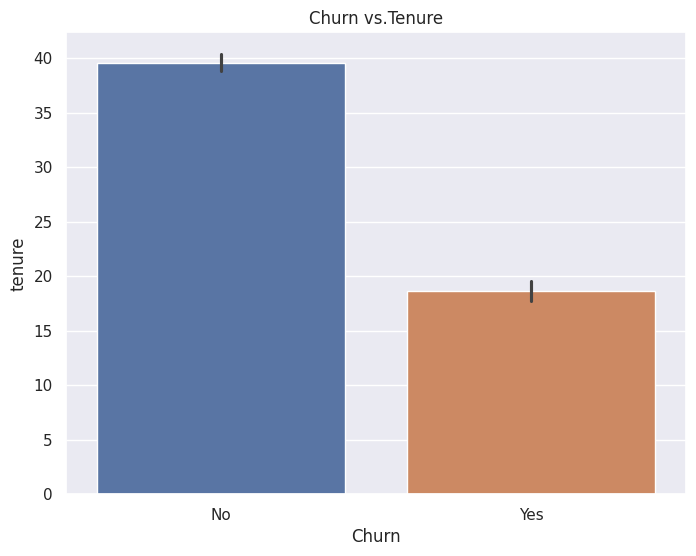

In [95]:
plt.figure(figsize=(8, 6))
sns.barplot(x="Churn", y="tenure", data=df, hue="Churn")
plt.title("Churn vs.Tenure")
plt.show()

**Customer churn rate is ~31.86%, which is significantly high and indicates potential revenue loss and retention issues.**

Calculating Churn rate by simple method.

In [96]:
total_customers = len(df)
churned_customers = len(df[df['Churn'] == 'Yes'])
churn_rate = (churned_customers / total_customers) * 100
print(churn_rate)

31.8577648766328


Simple Visualization: Seaborn Count Plot
A count plot is the most direct way to visualize the numbers used in the simple division formula.

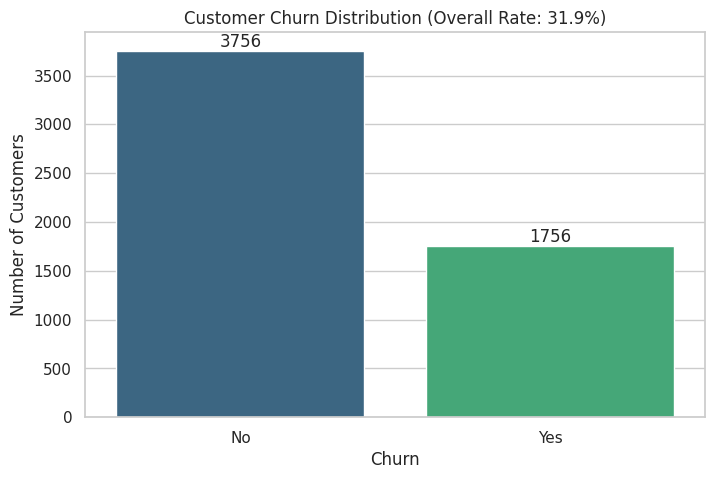

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the churn rate of customers
churn_rate = (len(df[df['Churn'] == 'Yes']) / len(df)) * 100

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Creating the count plot
ax = sns.countplot(x='Churn', hue='Churn', legend=False, data=df, palette='viridis')

# Adding labels and title
plt.title(f'Customer Churn Distribution (Overall Rate: {churn_rate:.1f}%)')
plt.ylabel('Number of Customers')

# Adding exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.show()

**Higher Monthly charges leading to higher Churn rate,i.e, price sensitivity.**

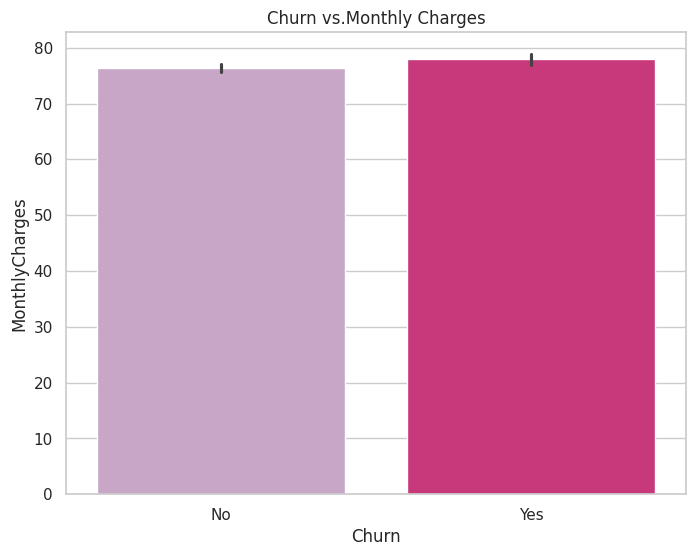

In [98]:
plt.figure(figsize=(8, 6))
sns.barplot(x="Churn", y="MonthlyCharges", data=df, hue="Churn", palette='PuRd')
plt.title("Churn vs.Monthly Charges")
plt.show()

**Lower total charges --> Higher Churn rate, because customers leave before long-term engagement.**

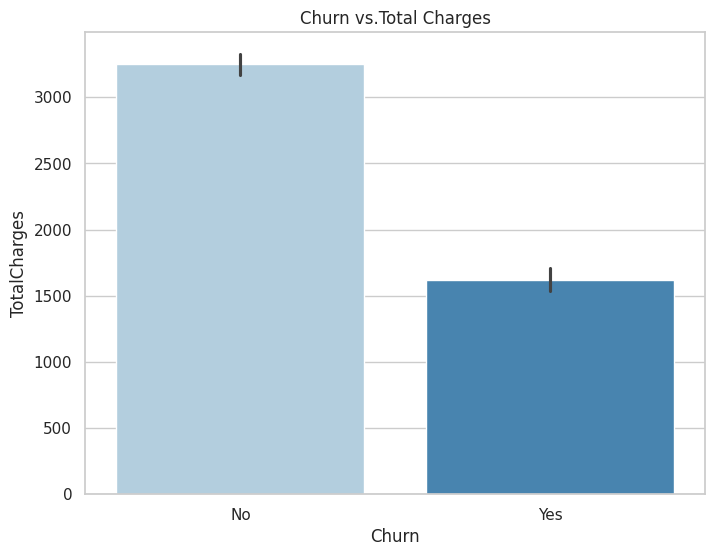

In [99]:
plt.figure(figsize=(8, 6))
sns.barplot(x="Churn", y="TotalCharges", data=df, hue="Churn", palette = 'Blues')
plt.title("Churn vs.Total Charges")
plt.show()

***key factors causing higher Churn rate are:***


**Low tenure (early-stage churn)**

**High monthly charges (price sensitivity)**

**Low total spend (lack of long-term engagement)**

**Further SEGMENTATION ANALYSIS**

<Axes: xlabel='Contract', ylabel='count'>

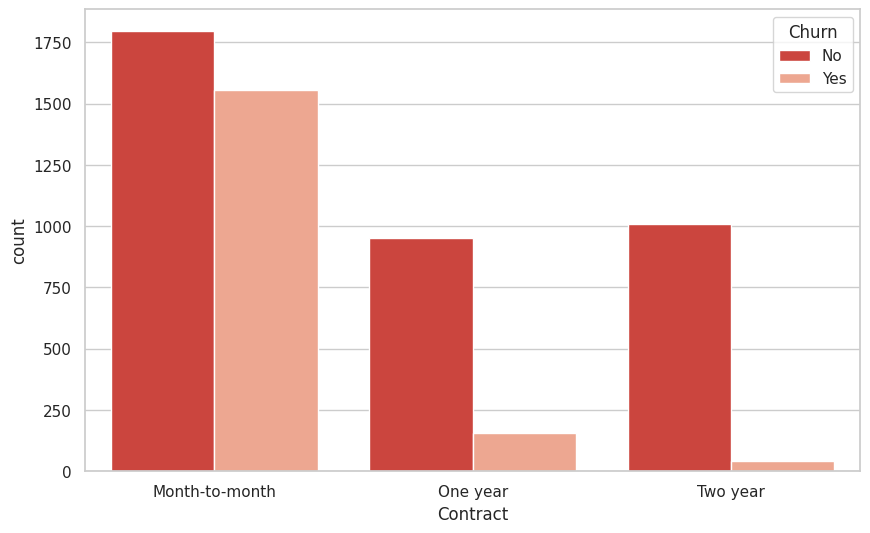

In [100]:
sns.countplot(x='Contract', hue='Churn', data=df, palette = 'Reds_r')

<Axes: xlabel='InternetService', ylabel='count'>

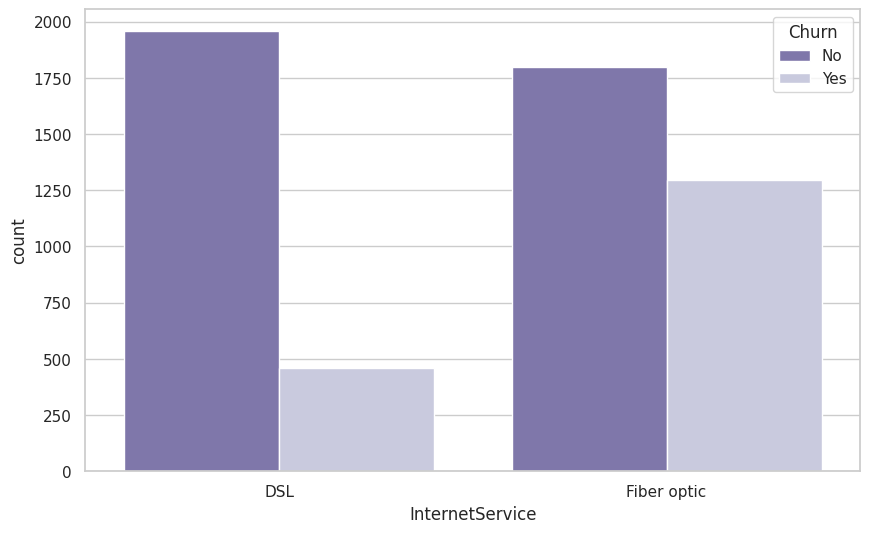

In [101]:
sns.countplot(x='InternetService', hue='Churn', data=df, palette = 'Purples_r')

<Axes: xlabel='PaymentMethod', ylabel='count'>

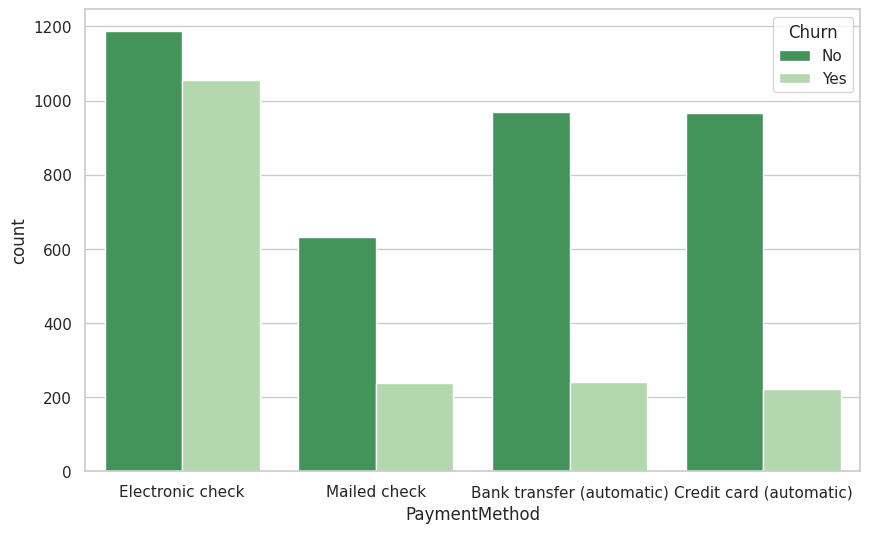

In [102]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette = 'Greens_r')

In [103]:
df = df.drop('customerID', axis = 1)

**Classification labels**

**Churn – Whether the customer churned or not (Yes or No)**

**Seperating the categorical and numerical features.**

In [104]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = df.drop(numerical_features, axis=1)

In [105]:
print(df.head())

   gender  tenure  MonthlyCharges  TotalCharges        Contract  \
0  Female       1           29.85         29.85  Month-to-month   
1    Male      34           56.95       1889.50        One year   
2    Male       2           53.85        108.15  Month-to-month   
3    Male      45           42.30       1840.75        One year   
4  Female       2           70.70        151.65  Month-to-month   

  InternetService              PaymentMethod tenure_group Churn  
0             DSL           Electronic check          New    No  
1             DSL               Mailed check        Loyal    No  
2             DSL               Mailed check          New   Yes  
3             DSL  Bank transfer (automatic)        Loyal    No  
4     Fiber optic           Electronic check          New   Yes  


In [106]:
print(numerical_features)

['tenure', 'MonthlyCharges', 'TotalCharges']


In [107]:
print(categorical_features)

      gender        Contract InternetService              PaymentMethod  \
0     Female  Month-to-month             DSL           Electronic check   
1       Male        One year             DSL               Mailed check   
2       Male  Month-to-month             DSL               Mailed check   
3       Male        One year             DSL  Bank transfer (automatic)   
4     Female  Month-to-month     Fiber optic           Electronic check   
...      ...             ...             ...                        ...   
5507    Male        One year             DSL               Mailed check   
5508  Female        One year     Fiber optic    Credit card (automatic)   
5509  Female  Month-to-month             DSL           Electronic check   
5510    Male  Month-to-month     Fiber optic               Mailed check   
5511    Male        Two year     Fiber optic  Bank transfer (automatic)   

     tenure_group Churn  
0             New    No  
1           Loyal    No  
2             New   Y

**SCALING THE NUMERICALS**

In [108]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Numerical_scaled = scaler.fit_transform(df[numerical_features])

Already did One - hot encoding on categorical_features which includes Churn, which was a mistake, and leads to data leakage problem. Hence, after that immediately seperated the target variable which is ***"Churn"*** here.

**ENCODING THE CATEGORICALS - One-hot Encoding**

In [ ]:
df = pd.get_dummies(df, drop_first=True)   #pandas for quick operations

**SEPERATING THE TARGET VARIABLE - Churn**

In [114]:
y = df['Churn_Yes']   # target
X = df.drop('Churn_Yes', axis=1)   # features only

In [115]:
X.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male',
       'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'tenure_group_Mid', 'tenure_group_New'],
      dtype='object')

In [118]:
y.name

'Churn_Yes'

Dropping tenure_group columns

In [119]:
X = X.drop(['tenure_group_Mid', 'tenure_group_New'], axis=1)

**TRAIN - TEST SPLIT**

In [121]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**ACCURACY = (Total Predictions / Correct Predictions)**

In [123]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#max_iter default value is 100, increasing the value of it may help converge and get a solution, and get the best fit model

logreg = LogisticRegression(max_iter=100000000).fit(X_train, y_train)
print("Training set score: {:.3f}".format(logreg.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test, y_test)))

Training set score: 0.764
Test set score: 0.754


**Coefficients**

In [124]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient
6,InternetService_Fiber optic,0.979470
8,PaymentMethod_Electronic check,0.483701
2,TotalCharges,0.000319
1,MonthlyCharges,-0.002258
0,tenure,-0.057975
7,PaymentMethod_Credit card (automatic),-0.072917
3,gender_Male,-0.081833
9,PaymentMethod_Mailed check,-0.085302
4,Contract_One year,-0.703629
5,Contract_Two year,-1.618935


**1 = churned (customer left)**


**0 = did not churn (customer stayed)**

In [126]:
print(df['Churn_Yes'].value_counts())
print(df['Churn_Yes'].unique())

Churn_Yes
False    3756
True     1756
Name: count, dtype: int64
[False  True]


In [127]:
from collections import Counter

# Basic count
print("Training set:", Counter(y_train))
print("Test set:", Counter(y_test))

Training set: Counter({False: 3010, True: 1399})
Test set: Counter({False: 746, True: 357})


In [128]:
y.value_counts(normalize=True)

,proportion
Churn_Yes,
False,0.681422
True,0.318578


**Performance Metrics for the model**

In [129]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

       False       0.79      0.86      0.83       746
        True       0.65      0.54      0.58       357

    accuracy                           0.75      1103
   macro avg       0.72      0.70      0.71      1103
weighted avg       0.75      0.75      0.75      1103

ROC-AUC: 0.8064185459706672


In [131]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=10000000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000000)

In [132]:
y_pred = model.predict(X_test)                       #for accuracy
y_prob = model.predict_proba(X_test)[:,1]            #for ROC

In [134]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.66      0.76       746
        True       0.54      0.81      0.64       357

    accuracy                           0.71      1103
   macro avg       0.71      0.74      0.70      1103
weighted avg       0.77      0.71      0.72      1103

ROC-AUC: 0.8060693446279317
[[496 250]
 [ 69 288]]


In [135]:
df.to_csv('Customer_Churn_Analysis_Logistic_Reg.csv')